In [1]:
# basic
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
# pre processing
from sklearn import preprocessing as pre
# NN
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import MSELoss
from torch_geometric.nn import GCNConv
# val and plot
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from loguru import logger as log
#from ..val import calculate_metrics
# plot
import matplotlib.pyplot as plt
# foundation model
from functools import reduce

/home/marcos/.pyenv/versions/3.10.13/envs/gnn-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

In [4]:
SEED = 1345
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)
warnings.filterwarnings('ignore')

## Data

In [5]:
sb = pd.read_parquet("/home/marcos/loader_03-04_2024.parquet")
sb.head()

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609


In [6]:
sb.columns

Index(['125960550', '230565994', '258781031', '43768720', '44072192',
       '44783654', '44783914', '44784438', '45833547', '47568123'],
      dtype='object')

In [7]:
# define X and Y
sbx = sb.query("index <= '2024-03-31 23:59:59'")
sbx.shape, sb.shape

((1238, 10), (3640, 10))

In [8]:
# define X and Y
sby = sb.query("index > '2024-03-31 23:59:59'")
sby.shape, sb.shape

((2402, 10), (3640, 10))

In [9]:
pred_len = abs(sbx.shape[0] - sb.shape[0])
pred_len

2402

In [10]:
sby.shape

(2402, 10)

In [11]:
## Grid Search

In [12]:
node = ["43768720"]
serie_train = sbx[node]
serie_test = sby[node]

sazonalidade =  7 * 40

In [13]:
#?Prophet

In [14]:
?ExponentialSmoothing

Init signature:
ExponentialSmoothing(
    endog,
    trend=None,
    damped_trend=False,
    seasonal=None,
    *,
    seasonal_periods=None,
    initialization_method='estimated',
    initial_level=None,
    initial_trend=None,
    initial_seasonal=None,
    use_boxcox=False,
    bounds=None,
    dates=None,
    freq=None,
    missing='none',
)
Docstring:     
Holt Winter's Exponential Smoothing

Parameters
----------
endog : array_like
    The time series to model.
trend : {"add", "mul", "additive", "multiplicative", None}, optional
    Type of trend component.
damped_trend : bool, optional
    Should the trend component be damped.
seasonal : {"add", "mul", "additive", "multiplicative", None}, optional
    Type of seasonal component.
seasonal_periods : int, optional
    The number of periods in a complete seasonal cycle, e.g., 4 for
    quarterly data or 7 for daily data with a weekly cycle.
initialization_method : str, optional
    Method for initialize the recursions. One of:

    

In [15]:
modelo = ExponentialSmoothing(
    serie_train,
    #trend='add',                # ou 'mul' se for melhor
    seasonal='add',             # ou 'mul'
    seasonal_periods=sazonalidade
)

resultado = modelo.fit()

In [16]:
y_pred = resultado.forecast(steps=pred_len)
y_true = serie_test.values

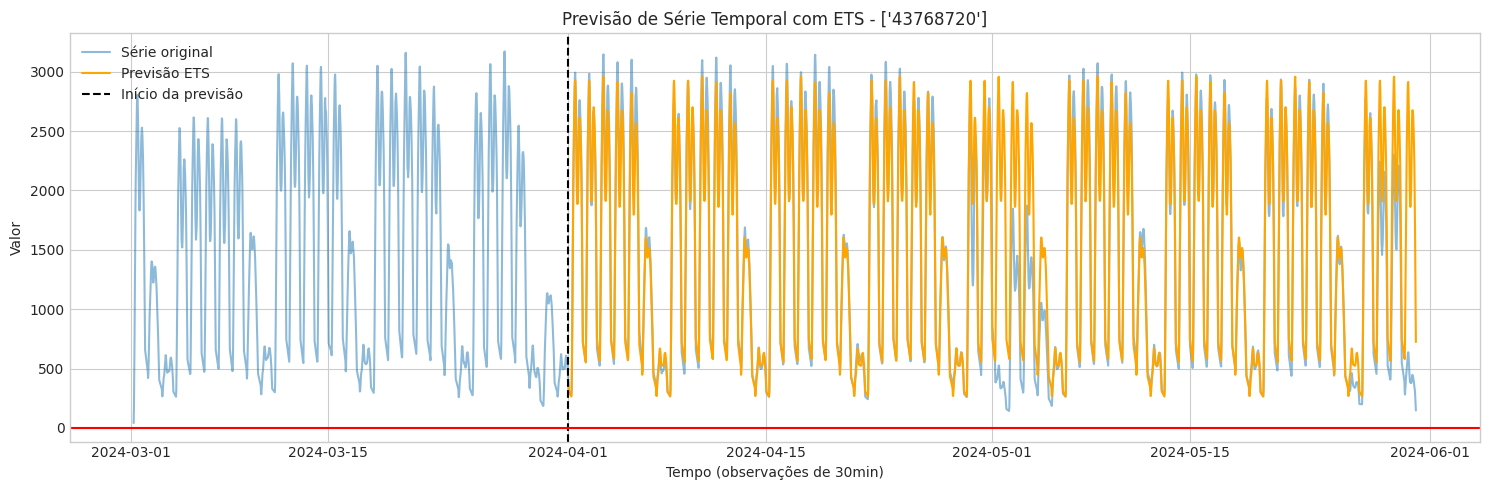

In [17]:
# t é a linha do tempo da série original
# Assumimos que sbx.index é o índice datetime de treino
t = pd.concat([sbx[node], sby[node]]).index

# série original completa
serie_completa = pd.concat([sbx[node], sby[node]])

# ponto onde a previsão começa
train_points = len(sbx)

plt.figure(figsize=(15,5))

# plot original
plt.plot(t, serie_completa, label="Série original", alpha=0.5)

# plot previsão
plt.plot(t[train_points:train_points+pred_len], y_pred, label="Previsão ETS", color="orange")

# linha de corte entre treino e predição
plt.axvline(x=t[train_points], color='k', linestyle='--', label="Início da previsão")

plt.legend()
plt.title(f"Previsão de Série Temporal com ETS - {node}")
plt.xlabel("Tempo (observações de 30min)")
plt.ylabel("Valor")
plt.axhline(0, c='r')
plt.grid(True)
plt.tight_layout()
plt.show()